In [ ]:
import scanpy as sc
import omicverse as ov
ov.plot_set()

## Anno raw data

In [2]:
adata=sc.read('data/GC_RNA/GC_ANNO.h5ad',compression='gzip')
adata

AnnData object with n_obs × n_vars = 148350 × 3000
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score', 'cell_abbreviations', 'log2umi', 'log2counts', 'pct_counts_mt'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 

In [4]:
adata_gc1=sc.read('data/GC_RNA/gc_raw.h5ad',compression='gzip')

In [5]:
adata_gc1.obs.head()

,sample_batch,initial_size_unspliced,initial_size_spliced,initial_size,hrr_name,Experiment,title,BioSample,patient,CancerType,Stage,CancerStage
HRR207233:AAACCTGAGGGTTCCC-1,TCCC-1,634,2455,2455.0,HRR207233,HRX168778,Expression-GC05T,GC05-Tumor,GC05,Mixed,T1bN2M0,T1
HRR207233:AAACCTGAGTAGGTGC-1,GTGC-1,1099,634,634.0,HRR207233,HRX168778,Expression-GC05T,GC05-Tumor,GC05,Mixed,T1bN2M0,T1
HRR207233:AAACCTGAGTGTACTC-1,ACTC-1,393,1451,1451.0,HRR207233,HRX168778,Expression-GC05T,GC05-Tumor,GC05,Mixed,T1bN2M0,T1
HRR207233:AAACCTGCATGGATGG-1,ATGG-1,541,1827,1827.0,HRR207233,HRX168778,Expression-GC05T,GC05-Tumor,GC05,Mixed,T1bN2M0,T1
HRR207233:AAACCTGGTATAATGG-1,ATGG-1,786,1753,1753.0,HRR207233,HRX168778,Expression-GC05T,GC05-Tumor,GC05,Mixed,T1bN2M0,T1


In [8]:
both_idx=list(set(adata.obs.index.tolist()) & set(adata_gc1.obs.index.tolist()))
len(both_idx)

79036

In [14]:
adata_gc1.obs['Tissue']=[i.split('-')[1] for i in adata_gc1.obs['BioSample'].tolist()]

In [15]:
adata_gc1.obs['Tissue'].unique()

array(['Tumor', 'Para', 'TIL'], dtype=object)

In [11]:
adata_gc1.obs['Stage'].unique()

['T1bN2M0', 'T4aN3aM0', 'T3N1M0', 'T3N3aM0', 'T4aN1M0', 'T2N1M0', 'T2N3aM0']
Categories (7, object): ['T1bN2M0', 'T2N1M0', 'T2N3aM0', 'T3N1M0', 'T3N3aM0', 'T4aN1M0', 'T4aN3aM0']

In [12]:
adata_gc1.obs['CancerStage'].unique()

['T1', 'T4', 'T3', 'T2']
Categories (4, object): ['T1', 'T2', 'T3', 'T4']

In [16]:
adata_gc1=adata_gc1[both_idx]
adata=adata[both_idx]

In [17]:
adata_gc1.obs

View of AnnData object with n_obs × n_vars = 79036 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'hrr_name', 'Experiment', 'title', 'BioSample', 'patient', 'CancerType', 'Stage', 'CancerStage', 'Tissue'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [22]:
for i in list(set(adata.obs.columns) - set(adata_gc1.obs.columns)):
    adata_gc1.obs[i]=adata.obs[i].tolist()
adata_gc1.obsm=adata.obsm.copy()
adata_gc1.obsp=adata.obsp.copy()
adata_gc1.uns=adata.uns.copy()

In [26]:
adata_gc1.write('data/GC_RNA/GC_VELO_ANNO.h5ad',compression='gzip')

## Map to sp

In [28]:
adata_sp=sc.read_visium('data/GC_ST/GSE245704_RAW')

reading data/GC_ST/GSE245704_RAW/filtered_feature_bc_matrix.h5
 (0:00:00)


In [29]:
adata_sp

AnnData object with n_obs × n_vars = 2560 × 18085
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [30]:
adata_sp=adata_sp[adata_sp.obs['in_tissue']==1]
adata_sp

View of AnnData object with n_obs × n_vars = 2560 × 18085
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [32]:
adata_sp.var_names_make_unique()

In [33]:
sc.pp.calculate_qc_metrics(adata_sp, inplace=True)
adata_sp = adata_sp[:,adata_sp.var['total_counts']>100]
adata_sp=ov.pp.preprocess(adata_sp,mode='shiftlog|pearson',n_HVGs=3000,target_sum=50*1e4)
adata_sp.raw = adata_sp
adata_sp = adata_sp[:, adata_sp.var.highly_variable_features]


Begin robust gene identification
After filtration, 15581/15581 genes are kept.     Among 15581 genes, 15581 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['IGKC', 'STAT1', 'NBEAL2', 'SLC6A19', 'GM2A', 'TMED9', 'SOD2', 'PSAP', 'KLRG1', 'EMP1', 'HBA2']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 1.022444725036621 seconds.
End of size normalization: shiftlog and HVGs selection pearson


In [35]:
import numpy as np
cleaned_indices = ~np.isnan(adata_sp.obsm['spatial']).any(axis=1)
adata_sp=adata_sp[cleaned_indices]

In [37]:
adata_sp.obs['X'] = adata_sp.obsm['spatial'][:,0]
adata_sp.obs['Y'] = adata_sp.obsm['spatial'][:,1]

In [38]:
adata_sp.var['highly_variable']=adata_sp.var['highly_variable_features']

In [39]:
# define model
model = ov.externel.GraphST.GraphST(adata_sp, device='cuda:0')

# train model
adata_sp = model.train(n_pcs=30)

Begin to train ST data...


100%|██████████| 600/600 [00:08<00:00, 73.70it/s]


Optimization finished for ST data!
computing PCA
    with n_comps=30
    finished (0:00:00)
GraphST embedding has been saved in adata.obsm["GraphST_embedding"]                         and adata.obsm["graphst|original|X_pca"]


In [41]:
ov.utils.cluster(adata_sp,use_rep='graphst|original|X_pca',method='mclust',n_components=10,
                 modelNames='EEV', random_state=112,
                )
adata_sp.obs['mclust_GraphST'] = ov.utils.refine_label(adata_sp, radius=20, key='mclust') 

running GaussianMixture clustering
finished: found 10 clusters and added
    'mclust', the cluster labels (adata.obs, categorical)


100%|██████████| 2560/2560 [00:00<00:00, 3679.12it/s]


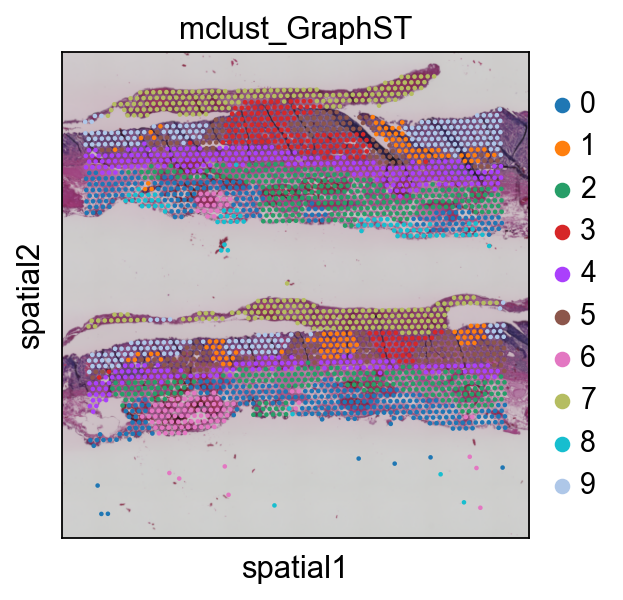

In [42]:
sc.pl.spatial(adata_sp, color=['mclust_GraphST'])

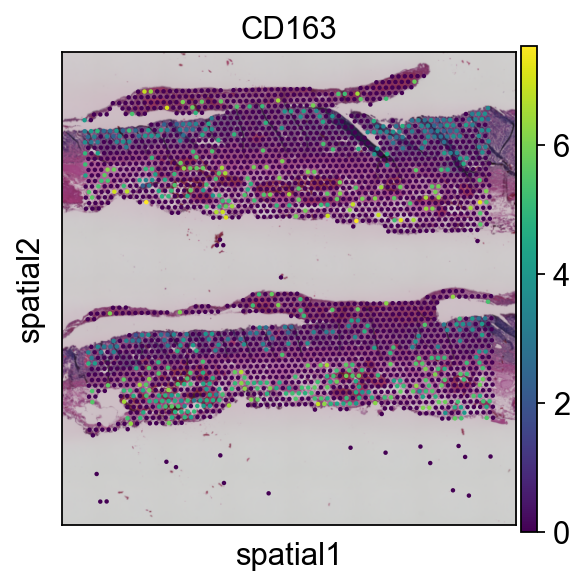

In [51]:
sc.pl.spatial(adata_sp, color=['CD163'])

In [65]:
adata_sp.write('data/GC_ST/GSE245704_RAW_mclust.h5ad',compression='gzip')

In [2]:
adata_sp=sc.read('data/GC_ST/GSE245704_RAW_mclust.h5ad',compression='gzip')

In [3]:
adata_gc1=sc.read('data/GC_RNA/GC_VELO_ANNO.h5ad',compression='gzip')

In [4]:
#adata_sc1=adata_sc[(adata_sc.obs['Tissue']=='Para')]
import random
cellidx=random.sample(adata_gc1.obs.index.tolist(),30000)
adata_sc1=adata_gc1[cellidx]

In [5]:
adata_sc1=ov.pp.preprocess(adata_sc1,mode='shiftlog|pearson',n_HVGs=3000,)
adata_sc1.raw=adata_sc1
adata_sc1=adata_sc1[:,adata_sc1.var.highly_variable_features]
adata_sc1

Begin robust gene identification
After filtration, 33064/38606 genes are kept.     Among 33064 genes, 24503 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'IGKC', 'IGKV4-1', 'IGKV1-5', 'IGKV1-6', 'IGKV3-7', 'IGKV1-8', 'IGKV1-9', 'IGKV3-11', 'IGKV1-12', 'IGKV3-15', 'IGKV1-16', 'IGKV1-17', 'IGKV3-20', 'IGKV6-21', 'IGKV2-24', 'IGKV1-27', 'IGKV2-28', 'IGKV2-29', 'IGKV2-30', 'IGKV1-33', 'IGKV1-39', 'IGKV2D-40', 'IGKV1D-39', 'IGKV1D-33', 'IGKV2D-29', 'IGKV2D-28', 'IGKV2D-24', 'IGKV6D-21', 'IGKV3D-20', 'IGKV3D-15', 'IGKV1D-13', 'GHRL', 'JCHAIN', 'PGC', 'DEFA5', 'HBB', 'PGA3', 'FTH1', 'MALAT1', 'IGHA1', 'IGHG1', 'IGHM', 'IGHV6-1', 'IGHV1-2', 'IGHV1-3', 'IGHV7-4-1', 'IGHV2-5', 'IGHV3-7', 'IGHV5-10-1', 'IGHV3-11', 'IGHV1-18', 'IGHV3-21', 'IGHV3-23', 'IGHV1-24', 'IGHV2-26', 'IGHV3-30', 'IGHV4-34',

View of AnnData object with n_obs × n_vars = 30000 × 3000
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'hrr_name', 'Experiment', 'title', 'BioSample', 'patient', 'CancerType', 'Stage', 'CancerStage', 'Tissue', 'cell_type_from_mulan_smoothing', 'leiden', 'predicted_doublet', 'nUMIs', 'best_clusters', 'gpt_celltype_0', 'cell_type_from_scMulan', 'celltype_gpt', 'Major_celltype', 'detected_genes', 'cell_abbreviations', 'cell_complexity', 'Minor_celltype', 'mito_perc', 'celltype_gbi', 'gpt_celltype_3', '_scvi_batch', 'smoothing_score', 'gpt_celltype_4', 'passing_ngenes', 'log2counts', 'gpt_celltype_1', 'doublet_score', 'gpt_celltype_2', 'pct_counts_mt', 'C_scANVI', 'log2umi', 'passing_nUMIs', 'n_genes', '_scvi_labels', 'passing_mt', 'best_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_

In [6]:
tg=ov.space.Tangram(adata_sc1,adata_sp,clusters='best_celltype')


tangram have been install version: 1.0.4
ranking genes
    finished: added to `.uns['best_celltype_rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
...Calculate The Number of Markers: 999


INFO:root:161 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:368 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


...Model prepared successfully


In [7]:
tg.train(mode="cells",num_epochs=500,device="cuda:0")

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 161 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.493, KL reg: 0.193
Score: 0.816, KL reg: 0.005
Score: 0.832, KL reg: 0.004
Score: 0.834, KL reg: 0.004
Score: 0.835, KL reg: 0.004


INFO:root:Saving results..
INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


...Model train successfully


In [8]:
adata_plot=tg.cell2location()
adata_plot.obs.columns

Index(['in_tissue', 'array_row', 'array_col', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'X', 'Y',
       'mclust', 'gmm_cluster', 'mclust_GraphST', 'uniform_density',
       'rna_count_based_density', 'Plasma cell', 'Enteroendocrine cell',
       'Pericyte', 'Enterocyte', 'Mast cell', 'Gastric Chief cell',
       'Gastric foveolar cell', 'T CD4+', 'Endothelial cell', 'Fibroblast',
       'Myeloid', 'Pyloric gland cell', 'B cell', 'T CD8+', 'Tuft cell'],
      dtype='object')

In [9]:
annotation_list=['Plasma cell', 'Fibroblast', 'Myeloid',
       'Gastric foveolar cell', 'T CD8+', 'Pericyte', 'T CD4+', 'Enterocyte',
       'Pyloric gland cell', 'Enteroendocrine cell', 'Gastric Chief cell',
       'Tuft cell', 'Endothelial cell', 'Mast cell', 'B cell']

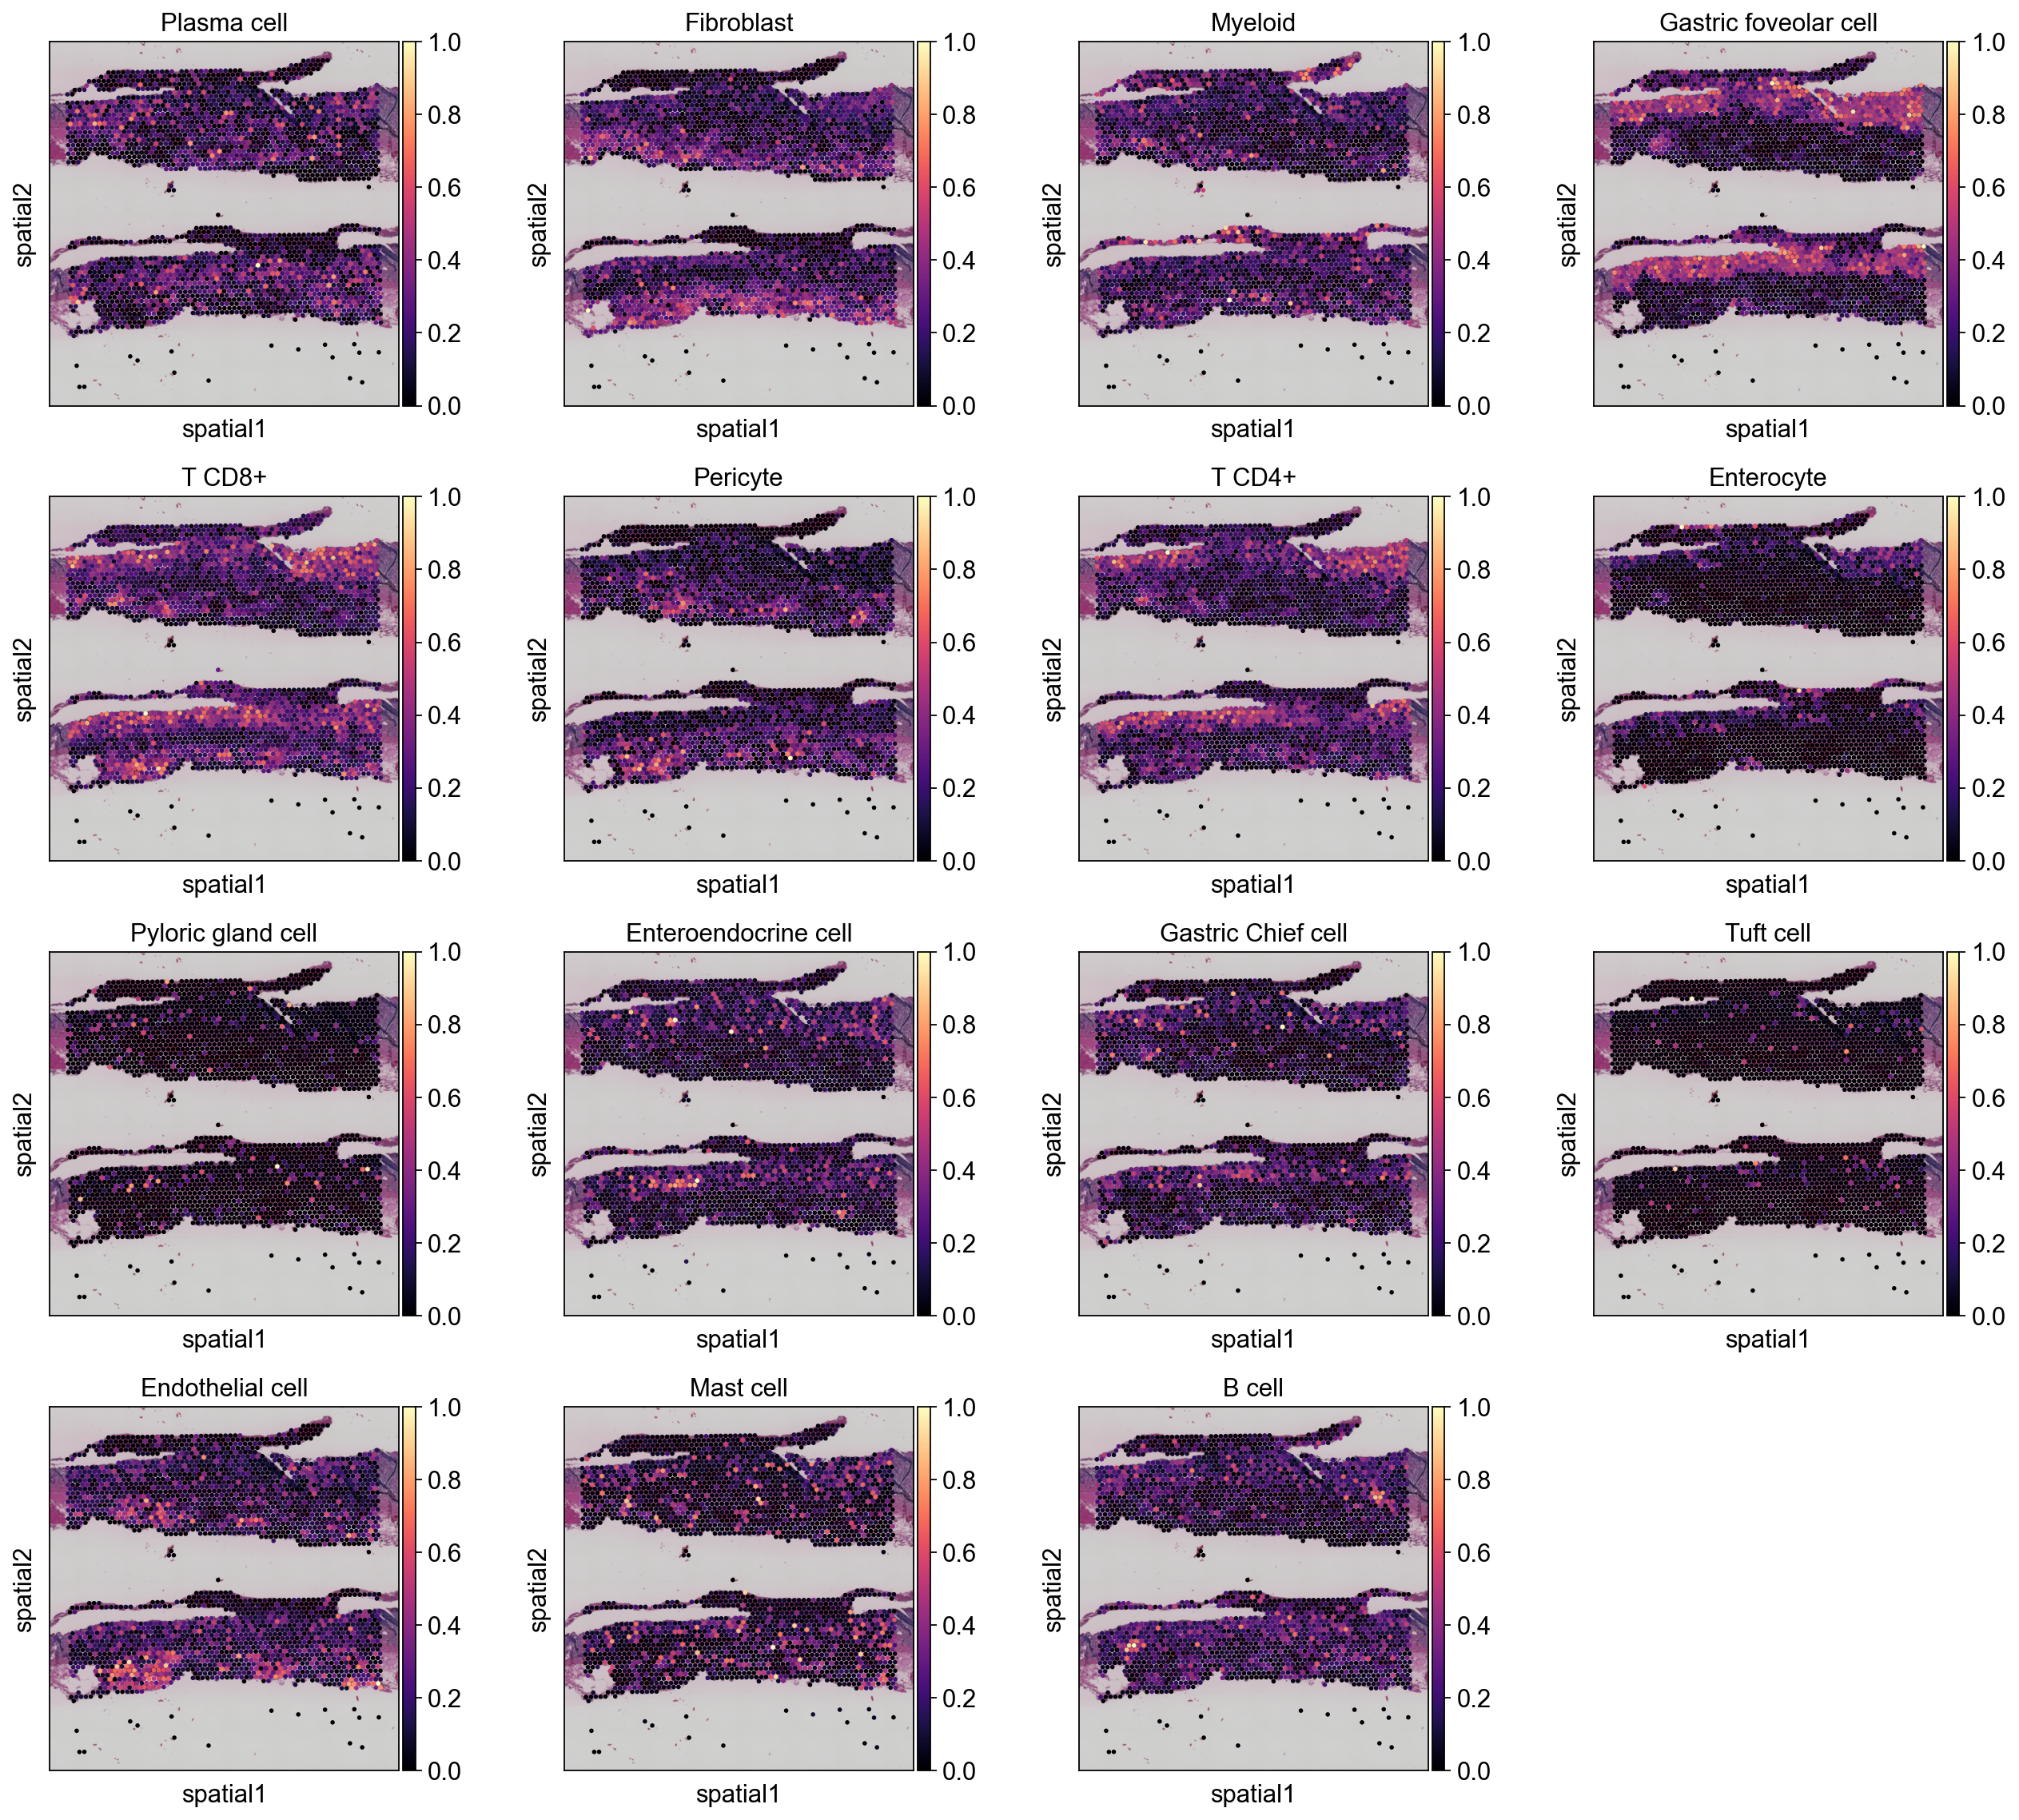

In [43]:
sc.pl.spatial(adata_plot, cmap='magma',
                  # show first 8 cell types
                  color=annotation_list,
                  ncols=4, size=1.3,
                  img_key='hires',
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

### T1

In [10]:
import random
adata_sc=adata_gc1[(adata_gc1.obs['CancerStage'].isin(['T3']))]
#adata_sc=adata_sc[(adata_sc.obs['Tissue']=='Para')]
if adata_sc.shape[0]>10000:
    cellidx=random.sample(adata_sc.obs.index.tolist(),10000)
    adata_sc=adata_sc[cellidx]
adata_sc

View of AnnData object with n_obs × n_vars = 10000 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'hrr_name', 'Experiment', 'title', 'BioSample', 'patient', 'CancerType', 'Stage', 'CancerStage', 'Tissue', 'cell_type_from_mulan_smoothing', 'leiden', 'predicted_doublet', 'nUMIs', 'best_clusters', 'gpt_celltype_0', 'cell_type_from_scMulan', 'celltype_gpt', 'Major_celltype', 'detected_genes', 'cell_abbreviations', 'cell_complexity', 'Minor_celltype', 'mito_perc', 'celltype_gbi', 'gpt_celltype_3', '_scvi_batch', 'smoothing_score', 'gpt_celltype_4', 'passing_ngenes', 'log2counts', 'gpt_celltype_1', 'doublet_score', 'gpt_celltype_2', 'pct_counts_mt', 'C_scANVI', 'log2umi', 'passing_nUMIs', 'n_genes', '_scvi_labels', 'passing_mt', 'best_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_c

<AxesSubplot: title={'center': 'best_celltype'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

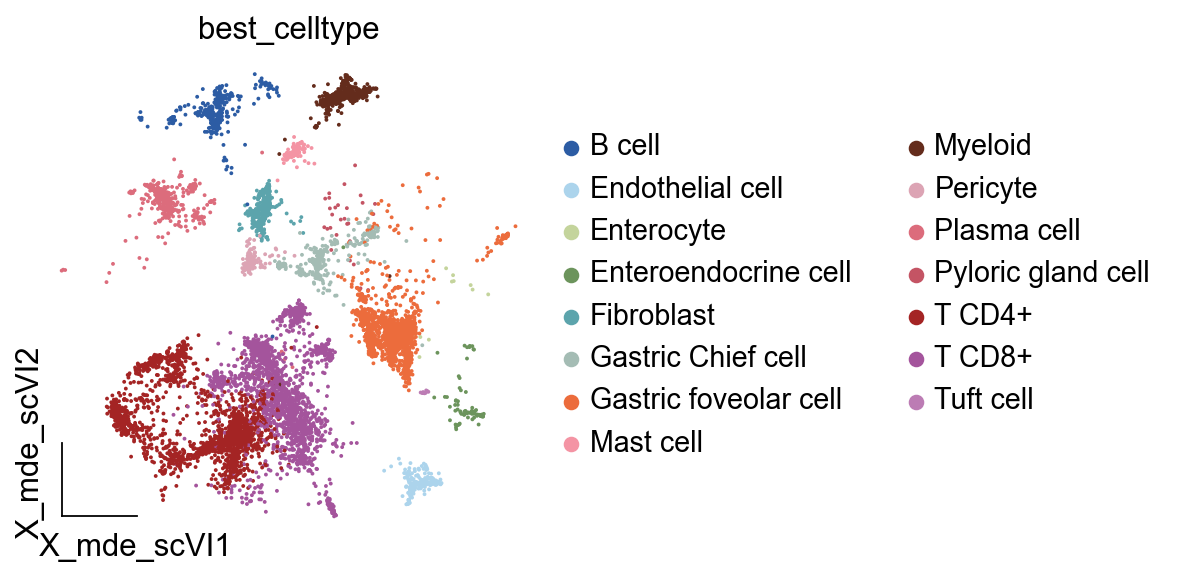

In [11]:
ov.utils.embedding(
    adata_sc,
    basis="X_mde_scVI",
    color=['best_celltype'],
    #title='Subset',
    frameon='small',
    #ncols=1,
    wspace=0.65,
    #palette=ov.utils.pyomic_palette()[11:],
    show=False,
    #ax=ax
)

In [12]:
adata_sc.X.max()

34984.0

In [13]:
adata_sc=ov.pp.preprocess(adata_sc,mode='shiftlog|pearson',n_HVGs=3000,)
adata_sc.raw=adata_sc
adata_sc=adata_sc[:,adata_sc.var.highly_variable_features]
adata_sc

Begin robust gene identification
After filtration, 31935/38606 genes are kept.     Among 31935 genes, 26153 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'IGKC', 'IGKV4-1', 'IGKV1-5', 'IGKV1-6', 'IGKV1-9', 'IGKV3-11', 'IGKV1-12', 'IGKV3-15', 'IGKV1-16', 'IGKV1-17', 'IGKV3-20', 'IGKV2-24', 'IGKV1-27', 'IGKV2-29', 'IGKV2-30', 'IGKV1-33', 'IGKV1-39', 'IGKV2D-40', 'IGKV1D-39', 'IGKV1D-33', 'IGKV2D-29', 'IGKV3D-15', 'GHRL', 'PGC', 'LIPF', 'HBB', 'PGA3', 'FTH1', 'MALAT1', 'IGHG1', 'IGHV6-1', 'IGHV1-3', 'IGHV2-5', 'IGHV3-7', 'IGHV5-10-1', 'IGHV3-13', 'IGHV1-18', 'IGHV3-23', 'IGHV1-24', 'IGHV2-26', 'IGHV3-30', 'IGHV4-34', 'IGHV4-39', 'IGHV1-46', 'IGHV3-48', 'IGHV5-51', 'IGHV4-59', 'IGHV1-69D', 'IGHV3-72', 'IGHV3-73', 'TTR', 'FTL', 'ENSG00000280441', 'IGLV4-69', 'IGLV8-61', 'IGLV6-57', 'IGLV10-

View of AnnData object with n_obs × n_vars = 10000 × 3000
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'hrr_name', 'Experiment', 'title', 'BioSample', 'patient', 'CancerType', 'Stage', 'CancerStage', 'Tissue', 'cell_type_from_mulan_smoothing', 'leiden', 'predicted_doublet', 'nUMIs', 'best_clusters', 'gpt_celltype_0', 'cell_type_from_scMulan', 'celltype_gpt', 'Major_celltype', 'detected_genes', 'cell_abbreviations', 'cell_complexity', 'Minor_celltype', 'mito_perc', 'celltype_gbi', 'gpt_celltype_3', '_scvi_batch', 'smoothing_score', 'gpt_celltype_4', 'passing_ngenes', 'log2counts', 'gpt_celltype_1', 'doublet_score', 'gpt_celltype_2', 'pct_counts_mt', 'C_scANVI', 'log2umi', 'passing_nUMIs', 'n_genes', '_scvi_labels', 'passing_mt', 'best_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_

In [14]:
cellmap=ov.space.CellLoc(adata_sc,adata_sp,use_rep_sc='X_scVI',
                    use_rep_sp='graphst|original|X_pca',)

In [15]:
map_pd=cellmap.loc_map(sc_type='best_celltype',sp_type='mclust',
            alpha=0.1,aware_power = 2,verbose=True,
            aware_spatial = True,aware_multi=True,use_gpu=True)

Calculating dissimilarity using euclidean distance on scaled data...
normalizing counts per cell
    finished (0:00:00)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
Constructing connectivity...
k = 10
aware_spatial = True
aware_multi = True
aware power = 2
Running OT...
alpha = 0.1
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|5.381636e-01|0.000000e+00|0.000000e+00
    1|4.829568e-01|1.143100e-01|5.520681e-02
    2|4.822629e-01|1.438724e-03|6.938435e-04
    3|4.821062e-01|3.250199e-04|1.566941e-04
    4|4.819041e-01|4.193616e-04|2.020921e-04
    5|4.817844e-01|2.486067e-04|1.197748e-04
    6|4.817646e-01|4.109599e-05|1.979859e-05
    7|4.817517e-01|2.667259e-05|1.284956e-05
    8|4.817268e-01|5.170239e-05|2.490643e-05
    9|4.816698e-01|1.184328e-04|5.704550e-05
   10|4.815515e-01|2.455045e-04|1.182231e-04
   11|4.813713e-01|3.743523e-04|1.802025e-04
   12|4.811691e-01|4.202673e-04|

In [16]:
cellmap.loc_prob(spot_cell_prob=adata_plot.obs[annotation_list],
                 sc_type='best_celltype',sc_prop=0.5,
                 n_cpu=8)

100%|██████████| 2560/2560 [00:00<00:00, 5144.48it/s]


INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [21]:
adata_sc_copy=cellmap.loc_assign(random = True,top_num = 5)


Assigning spatial coordinates to cells...
random = True
Maximum number of cells assigned to spots: 5
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Assignment done!
...assigning spatial coordinates to single cell data
...adding spatial coordinates to single cell data


In [22]:
adata_sc_copy

AnnData object with n_obs × n_vars = 4725 × 3000
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'hrr_name', 'Experiment', 'title', 'BioSample', 'patient', 'CancerType', 'Stage', 'CancerStage', 'Tissue', 'cell_type_from_mulan_smoothing', 'leiden', 'predicted_doublet', 'nUMIs', 'best_clusters', 'gpt_celltype_0', 'cell_type_from_scMulan', 'celltype_gpt', 'Major_celltype', 'detected_genes', 'cell_abbreviations', 'cell_complexity', 'Minor_celltype', 'mito_perc', 'celltype_gbi', 'gpt_celltype_3', '_scvi_batch', 'smoothing_score', 'gpt_celltype_4', 'passing_ngenes', 'log2counts', 'gpt_celltype_1', 'doublet_score', 'gpt_celltype_2', 'pct_counts_mt', 'C_scANVI', 'log2umi', 'passing_nUMIs', 'n_genes', '_scvi_labels', 'passing_mt', 'best_celltype', 'type', 'Cell_xcoord', 'Cell_ycoord', 'spot_type', 'spot', 'spot_value'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust

[<AxesSubplot: title={'center': 'best_celltype'}, xlabel='spatial1', ylabel='spatial2'>]

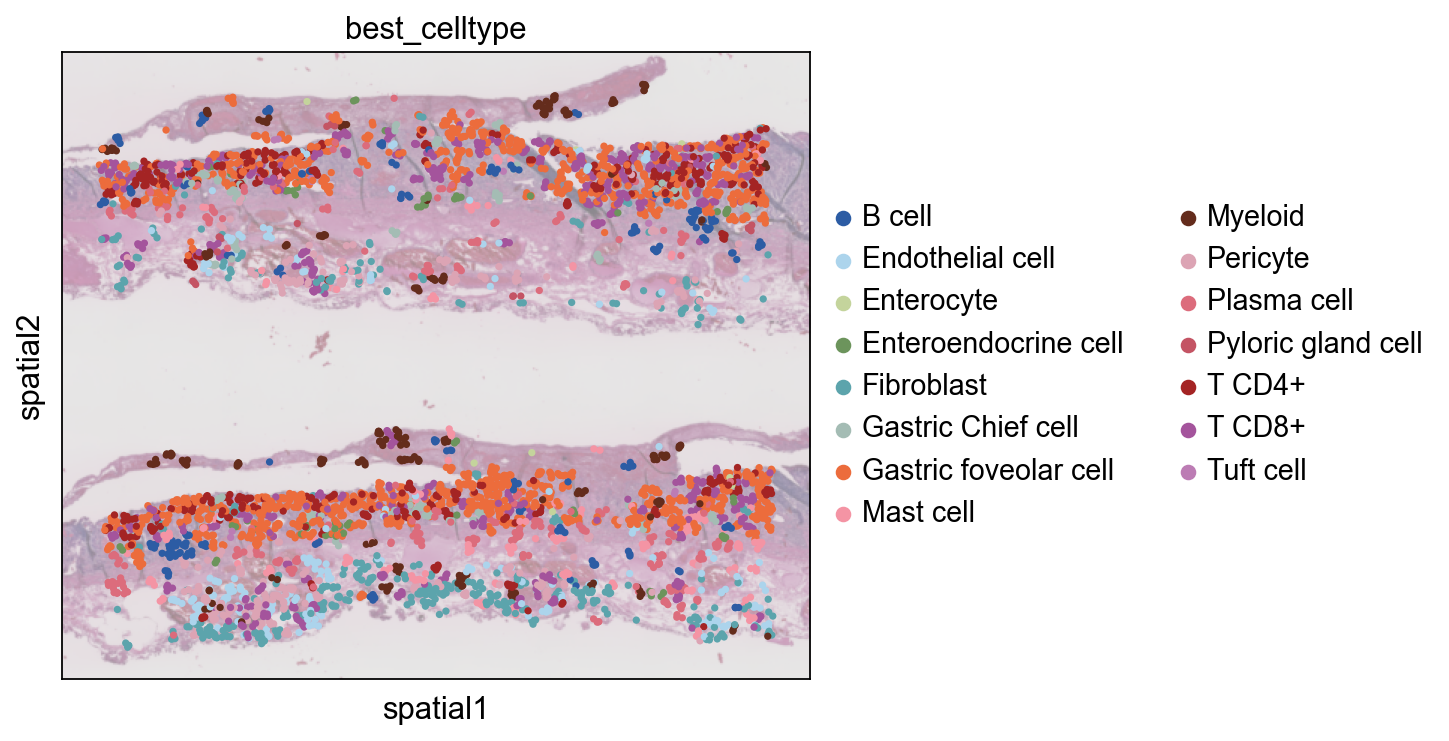

In [23]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.spatial(adata_sc_copy, cmap='magma',
                  # show first 8 cell types
                  color='best_celltype',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
              ax=ax,show=False
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

In [20]:
adata_sc_copy.write('data/GC_ST/GC_T3_mapping.h5ad',compression='gzip')

In [16]:
map_info=cellmap.spatrio_decon.copy()

In [18]:
from tqdm import tqdm
df=adata_plot.obs[annotation_list]

# 创建字典
first_max_dict = {}
first_max_value_dict = {}

# 找到每个索引得分第二高的列
for idx in tqdm(df.index):
    series = df.loc[idx]
    sorted_series = series.sort_values(ascending=False)
    third_max_value = sorted_series.iloc[0]  # 第三大的值
    third_max_column = list(df)[list(series).index(third_max_value)]  # 对应的列名
    first_max_dict[idx] = third_max_column
    first_max_value_dict[idx]=third_max_value

# 创建字典
second_max_dict = {}
second_max_value_dict = {}

# 找到每个索引得分第二高的列
for idx in tqdm(df.index):
    series = df.loc[idx]
    sorted_series = series.sort_values(ascending=False)
    third_max_value = sorted_series.iloc[1]  # 第三大的值
    third_max_column = list(df)[list(series).index(third_max_value)]  # 对应的列名
    second_max_dict[idx] = third_max_column
    second_max_value_dict[idx]=third_max_value

# 创建字典
third_max_dict = {}
third_max_value_dict = {}

# 找到每个索引得分第三高的列
for idx in tqdm(df.index):
    series = df.loc[idx]
    sorted_series = series.sort_values(ascending=False)
    third_max_value = sorted_series.iloc[2]  # 第三大的值
    third_max_column = list(df)[list(series).index(third_max_value)]  # 对应的列名
    third_max_dict[idx] = third_max_column
    third_max_value_dict[idx]=third_max_value


100%|██████████| 2560/2560 [00:00<00:00, 7169.51it/s]


In [19]:
sorted_cols

NameError: name 'sorted_cols' is not defined

In [20]:
map_info['spot_prop1']=map_info['spot'].map(first_max_dict)
map_info['spot_prop2']=map_info['spot'].map(second_max_dict)
map_info['spot_prop3']=map_info['spot'].map(third_max_dict)

map_info['spot_prop_value1']=map_info['spot'].map(first_max_value_dict)
map_info['spot_prop_value2']=map_info['spot'].map(second_max_value_dict)
map_info['spot_prop_value3']=map_info['spot'].map(third_max_value_dict)

map_info['cell_type']=map_info['cell'].map(dict(zip(
    adata_sc.obs.index.tolist(),
    adata_sc.obs['best_celltype'].tolist()   
)))

In [21]:
map_info

,spot,cell,value,spot_prop1,spot_prop2,spot_prop3,spot_prop_value1,spot_prop_value2,spot_prop_value3,cell_type
13197291,ATCCTCCAGCCATTGT-1,HRR207225:TCAGCTCTCAGGTAAA-1,1.000000e-04,Fibroblast,Plasma cell,T CD8+,0.358234,0.152805,0.127981,T CD4+
6451065,TGCCGGCATTATAGAT-1,HRR207224:CGAGCACGTTGGTAAA-1,1.000000e-04,Gastric foveolar cell,Plasma cell,T CD4+,0.277863,0.152218,0.117861,B cell
7332236,AGTATTCGTCGGTATC-1,HRR207225:ACGTCAAAGAGTCTGG-1,1.000000e-04,Myeloid,Fibroblast,Endothelial cell,0.328261,0.301688,0.229287,Plasma cell
22286033,CTTATTCACTAGCTGG-1,HRR207226:CTAACTTAGGTGGGTT-1,1.000000e-04,Fibroblast,Gastric foveolar cell,T CD8+,0.257311,0.208613,0.166679,T CD8+
5922819,GCTGTTATGGTTGCCG-1,HRR207226:CCCAATCTCTAACTCT-1,1.000000e-04,Gastric Chief cell,Fibroblast,Plasma cell,0.402788,0.320628,0.091590,T CD4+
...,...,...,...,...,...,...,...,...,...,...
8537082,TAGGACGGCCAGCCGA-1,HRR207225:CTTGGCTAGTAGCGGT-1,3.906250e-28,Fibroblast,Pericyte,Myeloid,0.588347,0.193818,0.092026,T CD4+
8537081,TAGCTTAAGCTGGCGT-1,HRR207225:CTTGGCTAGTAGCGGT-1,3.906250e-28,T CD8+,Gastric foveolar cell,T CD4+,0.612032,0.610060,0.475972,T CD4+
8537080,TAGCTATGTTGAGCAC-1,HRR207225:CTTGGCTAGTAGCGGT-1,3.906250e-28,Endothelial cell,B cell,Plasma cell,0.409010,0.279526,0.194558,T CD4+
8537079,TAGCTAGAGGCCTGAA-1,HRR207225:CTTGGCTAGTAGCGGT-1,3.906250e-28,Fibroblast,Plasma cell,Endothelial cell,0.153746,0.136773,0.090942,T CD4+


In [22]:
import pandas as pd
from pandarallel import pandarallel
from tqdm import tqdm

# 初始化 pandarallel
pandarallel.initialize(progress_bar=True)

# 假设 df 是你的 DataFrame
# 读取数据的代码，例如：df = pd.read_csv('your_file.csv')
df=map_info

# 定义一个函数来检查 cell_type 是否在 spot_prop1/2/3 中
# 定义一个函数来检查 cell_type 和概率条件
def check_conditions(row):
    in_props = row['cell_type'] in [row['spot_prop1'], row['spot_prop2'], row['spot_prop3']]
    prob_condition = (
        ((row['cell_type'] == row['spot_prop1']) and (row['spot_prop_value1'] > 0.5)) or
        ((row['cell_type'] == row['spot_prop2']) and (row['spot_prop_value2'] > 0.5)) or
        ((row['cell_type'] == row['spot_prop3']) and (row['spot_prop_value3'] > 0.5))
    )
    return (in_props and prob_condition)

# 使用 pandarallel 并行处理，并使用 tqdm 可视化进度
tqdm.pandas(desc="Processing")
filtered_df = df[df.parallel_apply(check_conditions, axis=1)]

INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [53]:
help(pandarallel)

Help on class pandarallel in module pandarallel.core:

class pandarallel(builtins.object)
 |  Class methods defined here:
 |  
 |  initialize(shm_size_mb=None, nb_workers=6, progress_bar=False, verbose=2, use_memory_fs: Optional[bool] = None) -> None from builtins.type
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)



In [29]:
map_info.loc[list(set(map_info.index.tolist()) - set(filtered_df.index.tolist())),'value']=-1

In [30]:
map_info1=map_info[['spot','cell','value']]

In [35]:
cellmap.spatrio_decon=map_info1

In [ ]:
from omicverse.externel.spatrio.spatrio import ot_alignment,assign_coord
spatrio_map = assign_coord(adata1 = cellmap.adata_sp,adata2 = cellmap.adata_sc,
                          out_data = cellmap.spatrio_decon,random = False,top_num = 5)
#self.adata_sp.obs=self.adata_sp.obs.join(spatrio_map.set_index('cell'))

cellmap.spatrio_map=spatrio_map

loc1=pd.DataFrame(cellmap.spatrio_map[['Cell_xcoord','Cell_ycoord','spot','spot_type',
                               'value']].values,
                  columns=['Cell_xcoord','Cell_ycoord','spot','spot_type','value'],
                  index=cellmap.spatrio_map['cell'].tolist())
print('...assigning spatial coordinates to single cell data')
adata_sc_copy=cellmap.adata_sc.copy()
adata_sc_copy=adata_sc_copy[loc1.index.tolist()]
adata_sc_copy.obs['Cell_xcoord']=loc1.loc[adata_sc_copy.obs.index,'Cell_xcoord'].tolist()
adata_sc_copy.obs['Cell_ycoord']=loc1.loc[adata_sc_copy.obs.index,'Cell_ycoord'].tolist()
adata_sc_copy.obs['spot_type']=loc1.loc[adata_sc_copy.obs.index,'spot_type'].tolist()
adata_sc_copy.obs['spot']=loc1.loc[adata_sc_copy.obs.index,'spot'].tolist()
adata_sc_copy.obs['spot_value']=loc1.loc[adata_sc_copy.obs.index,'value'].tolist()

print('...adding spatial coordinates to single cell data')
adata_sc_copy.obsm['spatial']=loc1.loc[adata_sc_copy.obs.index,
                                       ['Cell_xcoord','Cell_ycoord']].values
adata_sc_copy.uns['spatial']=cellmap.adata_sp.uns['spatial'].copy()

In [41]:
adata_sc_copy.obsm['spatial']=adata_sc_copy.obsm['spatial'].astype(float)

In [45]:
adata_sc_copy

AnnData object with n_obs × n_vars = 3156 × 3000
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'hrr_name', 'Experiment', 'title', 'BioSample', 'patient', 'CancerType', 'Stage', 'CancerStage', 'Tissue', 'cell_type_from_mulan_smoothing', 'leiden', 'predicted_doublet', 'nUMIs', 'best_clusters', 'gpt_celltype_0', 'cell_type_from_scMulan', 'celltype_gpt', 'Major_celltype', 'detected_genes', 'cell_abbreviations', 'cell_complexity', 'Minor_celltype', 'mito_perc', 'celltype_gbi', 'gpt_celltype_3', '_scvi_batch', 'smoothing_score', 'gpt_celltype_4', 'passing_ngenes', 'log2counts', 'gpt_celltype_1', 'doublet_score', 'gpt_celltype_2', 'pct_counts_mt', 'C_scANVI', 'log2umi', 'passing_nUMIs', 'n_genes', '_scvi_labels', 'passing_mt', 'best_celltype', 'type', 'Cell_xcoord', 'Cell_ycoord', 'spot_type', 'spot', 'spot_value'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust

In [47]:
del adata_sc_copy.obsm['reduction']

In [48]:
adata_sc_copy.write('data/GC_ST/GC_T2_mapping.h5ad',compression='gzip')

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.spatial(adata_sc_copy, cmap='magma',
                  # show first 8 cell types
                  color='best_celltype',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
              ax=ax,show=False
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

[<AxesSubplot: title={'center': 'best_celltype'}, xlabel='spatial1', ylabel='spatial2'>]

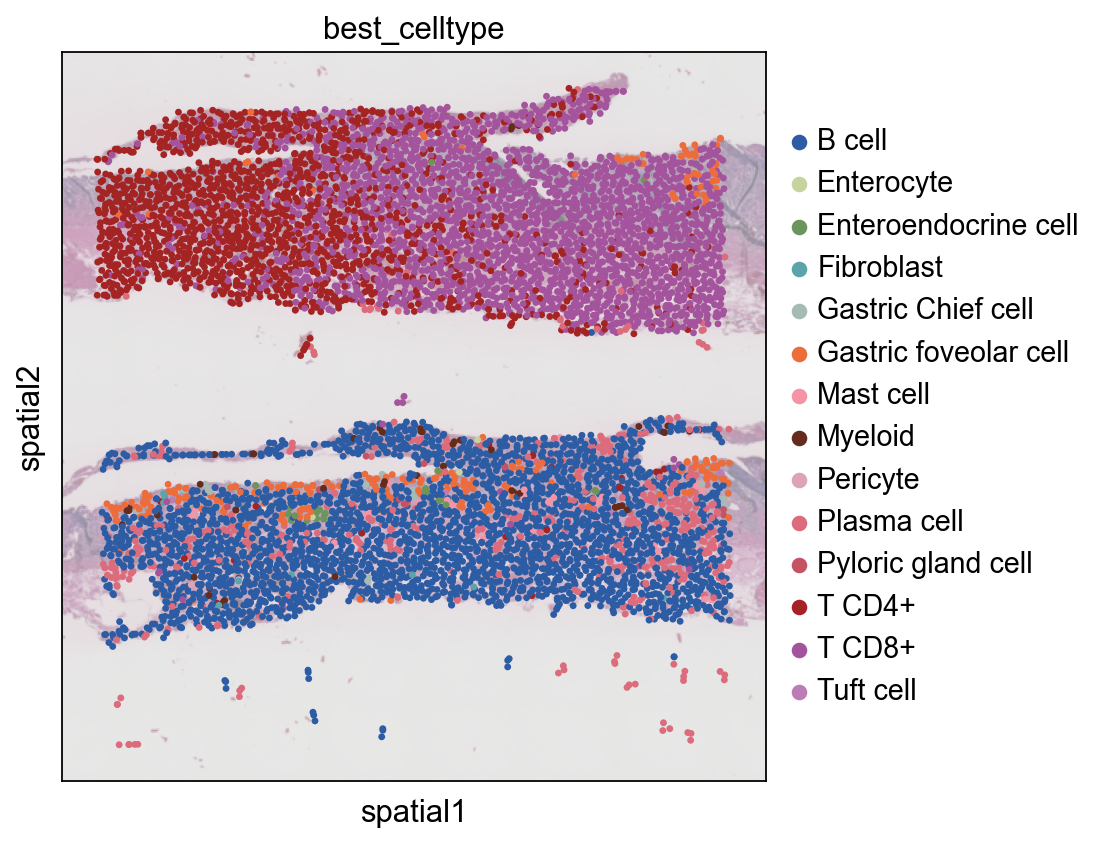

In [142]:
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.spatial(adata_sc, cmap='magma',
                  # show first 8 cell types
                  color='best_celltype',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
              ax=ax,show=False
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

In [101]:
sc.pl.spatial?

Signature:
sc.pl.spatial(
    adata: anndata._core.anndata.AnnData,
    *,
    color: str | collections.abc.Sequence[str] | None = None,
    mask_obs: numpy.ndarray[typing.Any, numpy.dtype[numpy.bool_]] | str | None = None,
    gene_symbols: str | None = None,
    use_raw: bool | None = None,
    sort_order: bool = True,
    edges: bool = False,
    edges_width: float = 0.1,
    edges_color: str | collections.abc.Sequence[float] | collections.abc.Sequence[str] = 'grey',
    neighbors_key: str | None = None,
    arrows: bool = False,
    arrows_kwds: collections.abc.Mapping[str, typing.Any] | None = None,
    groups: str | collections.abc.Sequence[str] | None = None,
    components: str | collections.abc.Sequence[str] | None = None,
    dimensions: tuple[int, int] | collections.abc.Sequence[tuple[int, int]] | None = None,
    layer: str | None = None,
    projection: Literal['2d', '3d'] = '2d',
    scale_factor: float | None = None,
    color_map: matplotlib.colors.Colormap | str | None

In [26]:
from typing import List, Tuple, Optional
import numpy as np
from anndata import AnnData
import scanpy as sc
import pandas as pd
from tqdm import tqdm
#
from scipy.optimize import nnls
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from scipy.stats import pearsonr
#from .helper import intersect, kl_divergence_backend, to_dense_array, extract_exp, extract_data_matrix, process_anndata, construct_graph, distances_cal, dist_cal, scale_num
from omicverse.externel.spatrio.helper import *

In [37]:
cellmap.spatrio_decon

,spot,cell,value
13197291,ATCCTCCAGCCATTGT-1,HRR207225:TCAGCTCTCAGGTAAA-1,-1.0
6451065,TGCCGGCATTATAGAT-1,HRR207224:CGAGCACGTTGGTAAA-1,-1.0
7332236,AGTATTCGTCGGTATC-1,HRR207225:ACGTCAAAGAGTCTGG-1,-1.0
22286033,CTTATTCACTAGCTGG-1,HRR207226:CTAACTTAGGTGGGTT-1,-1.0
5922819,GCTGTTATGGTTGCCG-1,HRR207226:CCCAATCTCTAACTCT-1,-1.0
...,...,...,...
8537082,TAGGACGGCCAGCCGA-1,HRR207225:CTTGGCTAGTAGCGGT-1,-1.0
8537081,TAGCTTAAGCTGGCGT-1,HRR207225:CTTGGCTAGTAGCGGT-1,-1.0
8537080,TAGCTATGTTGAGCAC-1,HRR207225:CTTGGCTAGTAGCGGT-1,-1.0
8537079,TAGCTAGAGGCCTGAA-1,HRR207225:CTTGGCTAGTAGCGGT-1,-1.0


In [38]:
spatrio_map = assign_coord(adata1 = cellmap.adata_sp,adata2 = cellmap.adata_sc,
                          out_data = cellmap.spatrio_decon,random = False,top_num = 5)

Assigning spatial coordinates to cells...
random = False
Maximum number of cells assigned to spots: 5
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
There are 2560 spots and 741 of them were assigned cells.


100%|██████████| 741/741 [00:28<00:00, 26.00it/s]

Assignment done!


In [39]:
cellmap.spatrio_map=spatrio_map

loc1=pd.DataFrame(cellmap.spatrio_map[['Cell_xcoord','Cell_ycoord','spot','spot_type',
                               'value']].values,
                  columns=['Cell_xcoord','Cell_ycoord','spot','spot_type','value'],
                  index=cellmap.spatrio_map['cell'].tolist())
print('...assigning spatial coordinates to single cell data')
adata_sc_copy=cellmap.adata_sc.copy()
adata_sc_copy=adata_sc_copy[loc1.index.tolist()]
adata_sc_copy.obs['Cell_xcoord']=loc1.loc[adata_sc_copy.obs.index,'Cell_xcoord'].tolist()
adata_sc_copy.obs['Cell_ycoord']=loc1.loc[adata_sc_copy.obs.index,'Cell_ycoord'].tolist()
adata_sc_copy.obs['spot_type']=loc1.loc[adata_sc_copy.obs.index,'spot_type'].tolist()
adata_sc_copy.obs['spot']=loc1.loc[adata_sc_copy.obs.index,'spot'].tolist()
adata_sc_copy.obs['spot_value']=loc1.loc[adata_sc_copy.obs.index,'value'].tolist()

print('...adding spatial coordinates to single cell data')
adata_sc_copy.obsm['spatial']=loc1.loc[adata_sc_copy.obs.index,
                                       ['Cell_xcoord','Cell_ycoord']].values
adata_sc_copy.uns['spatial']=cellmap.adata_sp.uns['spatial'].copy()

...assigning spatial coordinates to single cell data
...adding spatial coordinates to single cell data


[<AxesSubplot: title={'center': 'best_celltype'}, xlabel='spatial1', ylabel='spatial2'>]

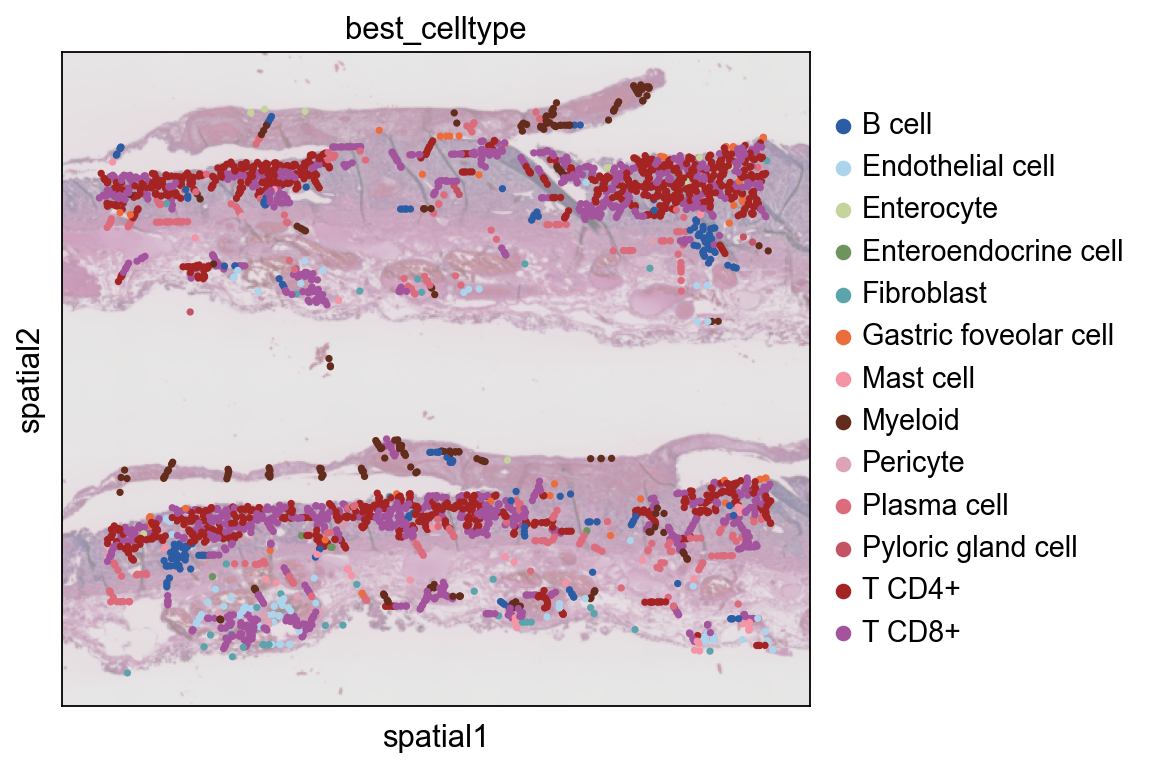

In [40]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.spatial(adata_sc_copy, cmap='magma',
                  # show first 8 cell types
                  color='best_celltype',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
              ax=ax,show=False
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )